    Age  Gender  Weight (kg)  Height (m) Max_BPM  Avg_BPM  Resting_BPM  \
0  34.0  Female         86.7        1.86     174    152.0         74.0   
1  26.0  Female         84.7        1.83     166    156.0         73.0   
2  22.0    Male         64.8        1.85     187    166.0         64.0   
3  54.0  Female         75.3        1.82     187    169.0         58.0   
4  34.0  Female         52.8        1.74     177    169.0         66.0   

   Session_Duration (hours)  Calories_Burned Workout_Type  Fat_Percentage  \
0                      1.12            712.0     Strength            12.8   
1                      1.00            833.0     Strength            27.9   
2                      1.24           1678.0       Cardio            28.7   
3                      1.45            628.0       Cardio            31.8   
4                      1.60           1286.0     Strength            26.4   

   Water_Intake (liters)  Workout_Frequency (days/week)  Experience_Level  \
0              

/tmp/ipykernel_13715/11930729.py:25: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_life["smokes"] = df_life["smokes"].replace({"yes":1,"no":0,"1":1,"0":0})


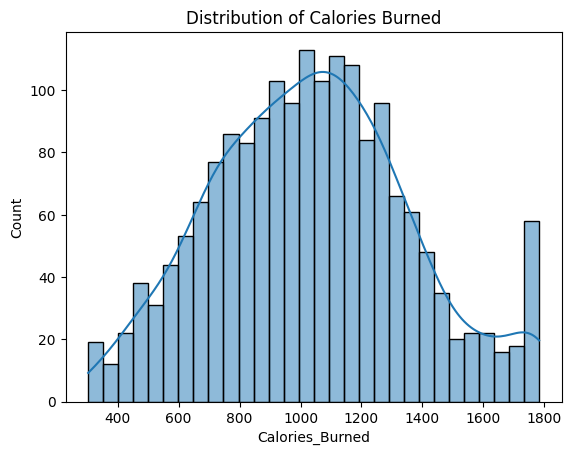

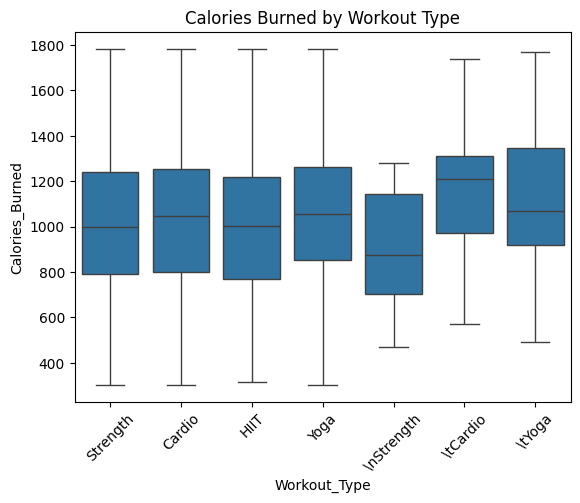

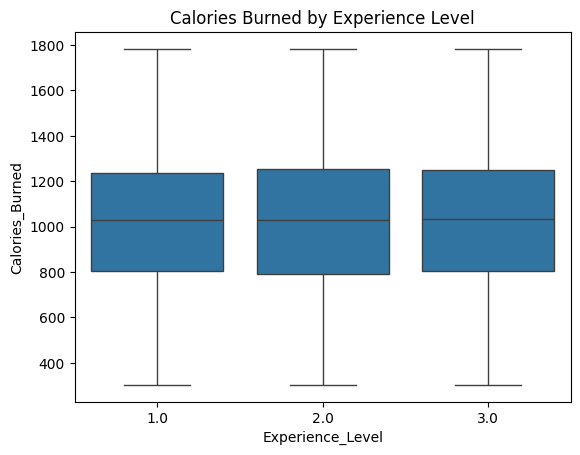

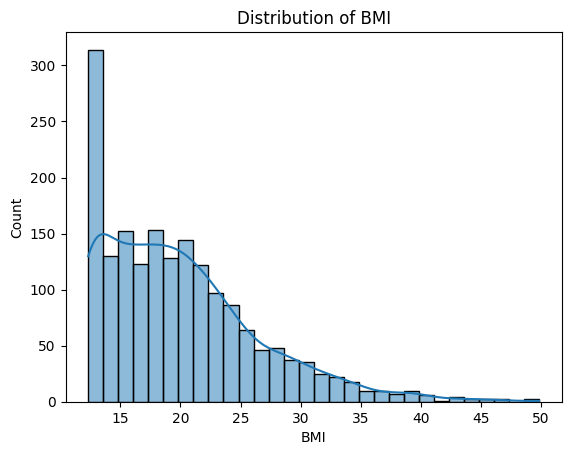

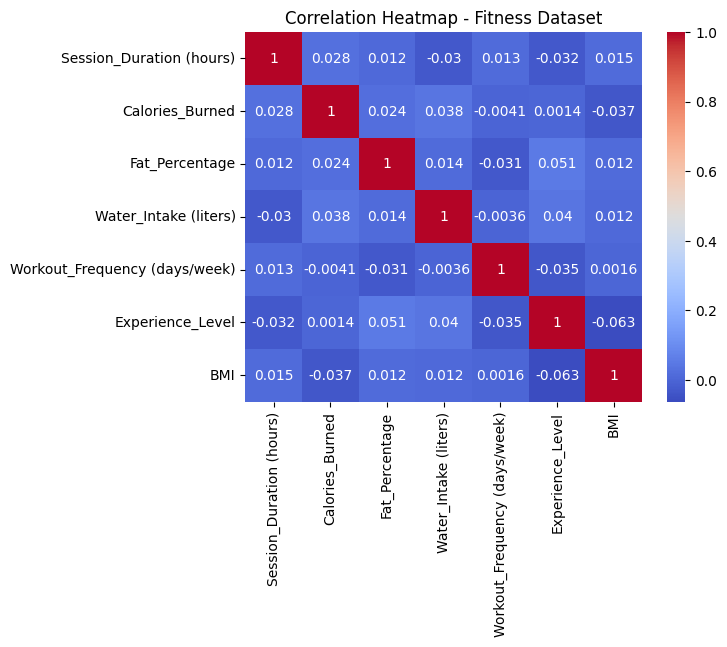

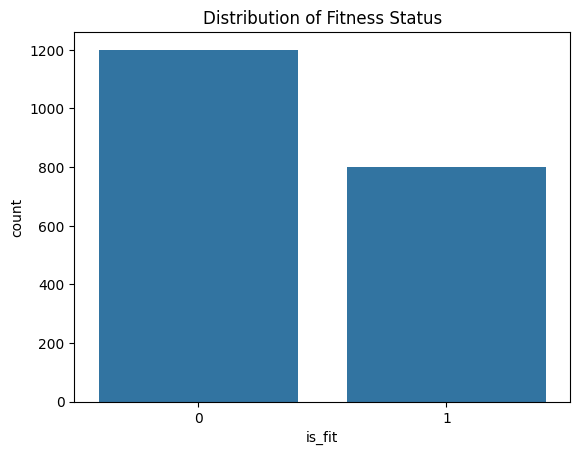

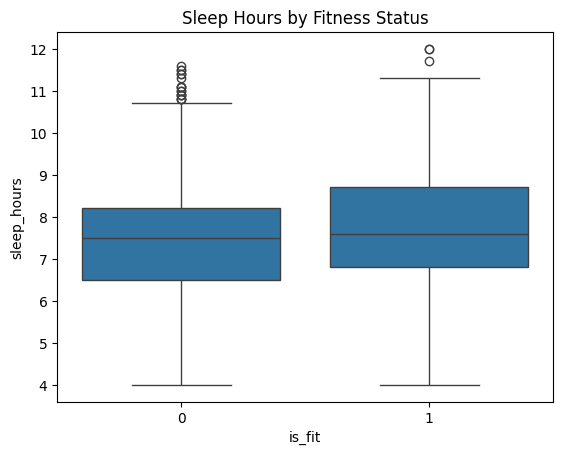

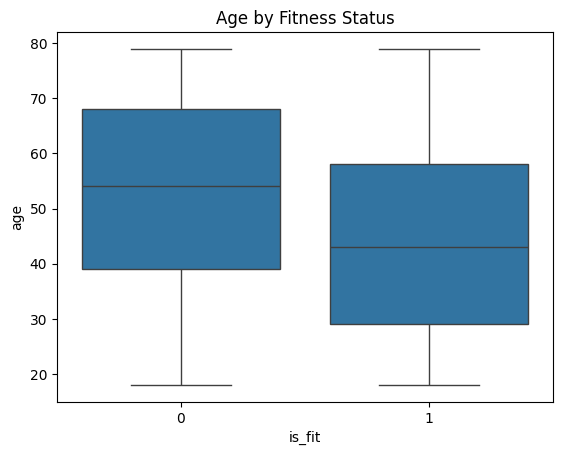

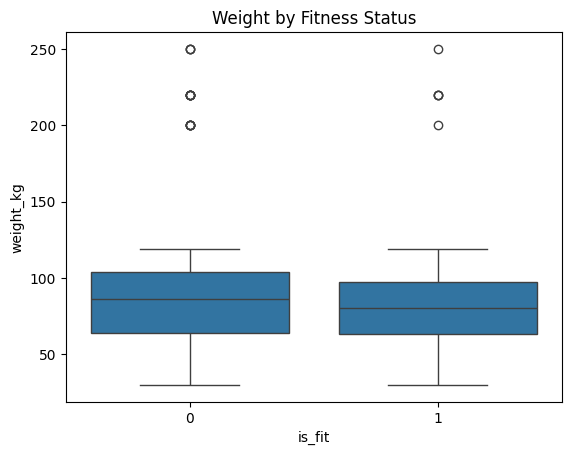

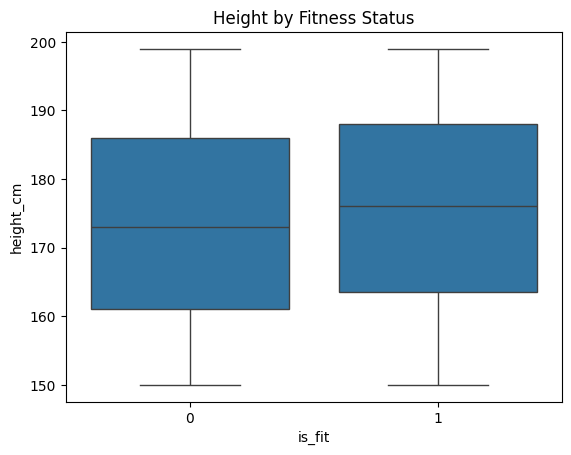

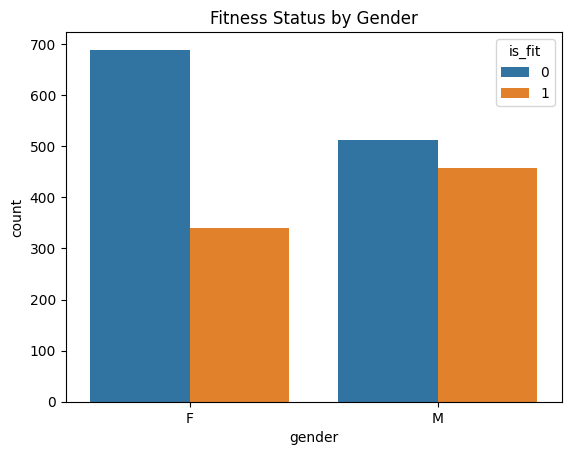

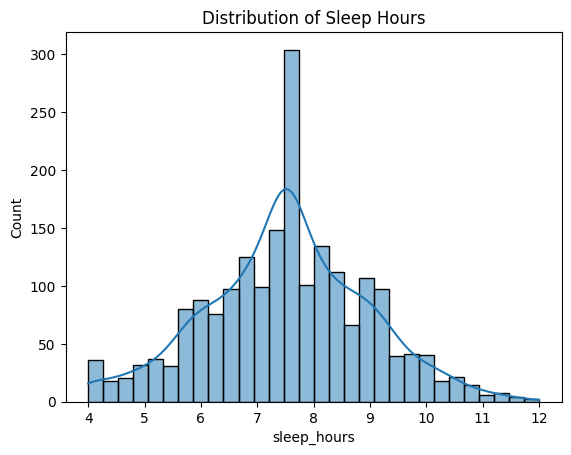

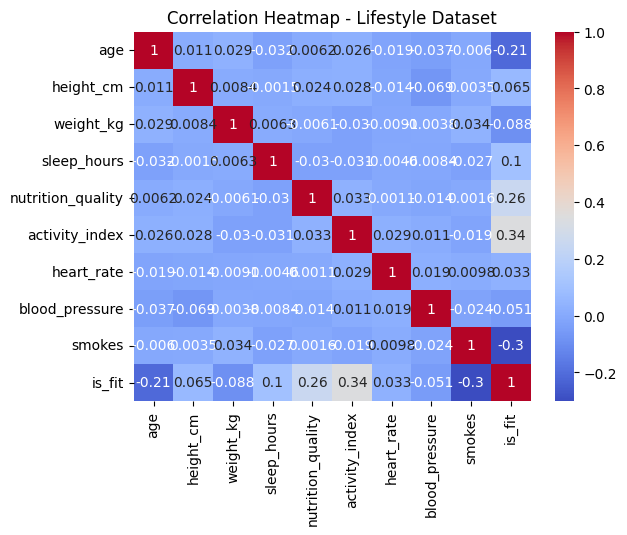

T-test for workout frequency vs calories burned:
TtestResult(statistic=np.float64(-0.8099353124744239), pvalue=np.float64(0.41808453191181627), df=np.float64(1798.0))

T-test for fitness status vs sleep hours:
TtestResult(statistic=np.float64(4.699971589322007), pvalue=np.float64(2.779544376312277e-06), df=np.float64(1998.0))

T-test for smoking status vs heart rate:
TtestResult(statistic=np.float64(0.4372233049268743), pvalue=np.float64(0.6619966616725126), df=np.float64(1998.0))

ANOVA for workout type vs calories burned:
F_onewayResult(statistic=np.float64(2.063195333894718), pvalue=np.float64(0.0545934281038816))

T-test for fitness status vs age:
TtestResult(statistic=np.float64(-9.792534593044591), pvalue=np.float64(3.7841094362539743e-22), df=np.float64(1998.0))

T-test for fitness status vs weight:
TtestResult(statistic=np.float64(-3.950302958591027), pvalue=np.float64(8.07614396508611e-05), df=np.float64(1998.0))
Logistic Regression Accuracy: 0.7725
Logistic Regression ROC AUC

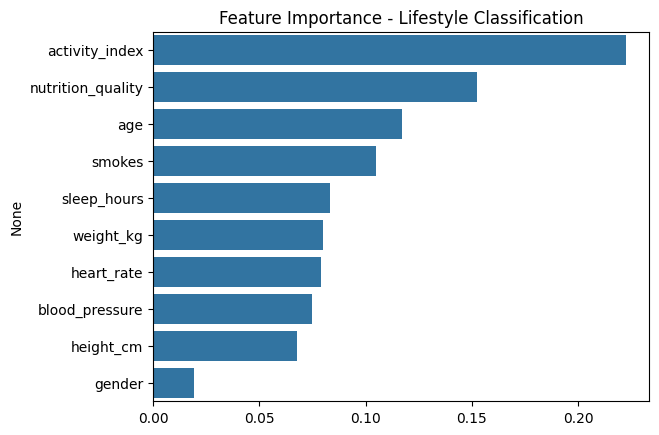


Linear Regression R2: 0.004721674100485962
Linear Regression RMSE: 316.7923833650216

Random Forest Regressor R2: -0.026907795006012813
Random Forest Regressor RMSE: 321.78676910983535

Linear Regression CV R2: -0.0054560368015671434
Random Forest Regressor CV R2: -0.03483179949770465

Fitness Feature Importance:
BMI                              0.244480
Fat_Percentage                   0.239525
Session_Duration (hours)         0.198537
Water_Intake (liters)            0.140261
Workout_Frequency (days/week)    0.066777
Experience_Level                 0.041629
Workout_Type_Yoga                0.020848
Workout_Type_Strength            0.019382
Workout_Type_HIIT                0.018987
Workout_Type_\tCardio            0.003621
Workout_Type_\nStrength          0.003006
Workout_Type_\tYoga              0.002948
dtype: float64


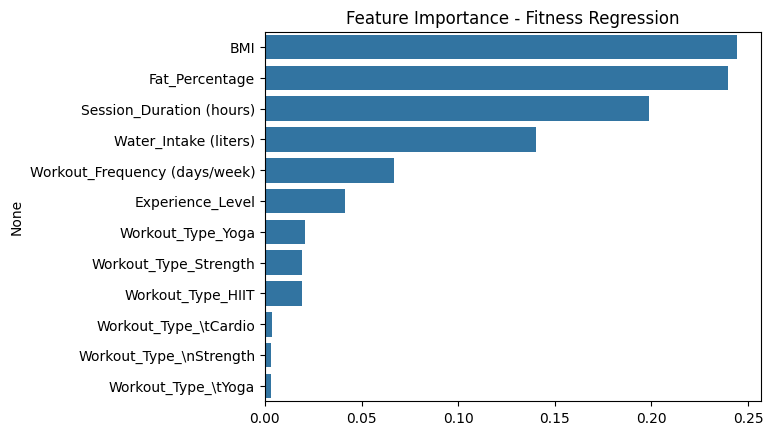

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, f_oneway
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

df_fit = pd.read_csv("gym_members_exercise_tracking_synthetic_data.csv")
df_life = pd.read_csv("fitness_dataset.csv")

print(df_fit.head())
print(df_life.head())
print(df_fit.columns.tolist())
print(df_life.columns.tolist())
print(df_fit.isnull().sum())
print()
print(df_life.isnull().sum())

df_life["sleep_hours"] = df_life["sleep_hours"].fillna(df_life["sleep_hours"].mean())
df_life["smokes"] = df_life["smokes"].replace({"yes":1,"no":0,"1":1,"0":0})
df_life["smokes"] = df_life["smokes"].astype(int)

print(df_life["smokes"].unique())
print(df_life["sleep_hours"].isnull().sum())

df_fit_use = df_fit[["Session_Duration (hours)","Calories_Burned","Workout_Type","Fat_Percentage","Water_Intake (liters)","Workout_Frequency (days/week)","Experience_Level","BMI"]].copy()
df_life_use = df_life[["age","gender","height_cm","weight_kg","sleep_hours","nutrition_quality","activity_index","heart_rate","blood_pressure","smokes","is_fit"]].copy()

print(df_fit_use.head())
print(df_life_use.head())
print(df_fit_use.shape)
print(df_life_use.shape)
print()
print(df_fit_use.isnull().sum())
print()
print(df_life_use.isnull().sum())

df_fit_use["Session_Duration (hours)"] = df_fit_use["Session_Duration (hours)"].fillna(df_fit_use["Session_Duration (hours)"].mean())
df_fit_use["Calories_Burned"] = df_fit_use["Calories_Burned"].fillna(df_fit_use["Calories_Burned"].mean())
df_fit_use["Fat_Percentage"] = df_fit_use["Fat_Percentage"].fillna(df_fit_use["Fat_Percentage"].mean())
df_fit_use["Water_Intake (liters)"] = df_fit_use["Water_Intake (liters)"].fillna(df_fit_use["Water_Intake (liters)"].mean())
df_fit_use["Workout_Frequency (days/week)"] = df_fit_use["Workout_Frequency (days/week)"].fillna(df_fit_use["Workout_Frequency (days/week)"].mean())
df_fit_use["BMI"] = df_fit_use["BMI"].fillna(df_fit_use["BMI"].mean())
df_fit_use["Workout_Type"] = df_fit_use["Workout_Type"].fillna(df_fit_use["Workout_Type"].mode()[0])
df_fit_use["Experience_Level"] = df_fit_use["Experience_Level"].fillna(df_fit_use["Experience_Level"].mode()[0])

print("Fitness dataset missing values after cleaning:")
print(df_fit_use.isnull().sum())
print()
print("Lifestyle dataset missing values after cleaning:")
print(df_life_use.isnull().sum())

sns.histplot(df_fit_use["Calories_Burned"], bins=30, kde=True)
plt.title("Distribution of Calories Burned")
plt.show()

sns.boxplot(x="Workout_Type", y="Calories_Burned", data=df_fit_use)
plt.xticks(rotation=45)
plt.title("Calories Burned by Workout Type")
plt.show()

sns.boxplot(x="Experience_Level", y="Calories_Burned", data=df_fit_use)
plt.title("Calories Burned by Experience Level")
plt.show()

sns.histplot(df_fit_use["BMI"], bins=30, kde=True)
plt.title("Distribution of BMI")
plt.show()

sns.heatmap(df_fit_use.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap - Fitness Dataset")
plt.show()

sns.countplot(x="is_fit", data=df_life_use)
plt.title("Distribution of Fitness Status")
plt.show()

sns.boxplot(x="is_fit", y="sleep_hours", data=df_life_use)
plt.title("Sleep Hours by Fitness Status")
plt.show()

sns.boxplot(x="is_fit", y="age", data=df_life_use)
plt.title("Age by Fitness Status")
plt.show()

sns.boxplot(x="is_fit", y="weight_kg", data=df_life_use)
plt.title("Weight by Fitness Status")
plt.show()

sns.boxplot(x="is_fit", y="height_cm", data=df_life_use)
plt.title("Height by Fitness Status")
plt.show()

sns.countplot(x="gender", hue="is_fit", data=df_life_use)
plt.title("Fitness Status by Gender")
plt.show()

sns.histplot(df_life_use["sleep_hours"], bins=30, kde=True)
plt.title("Distribution of Sleep Hours")
plt.show()

sns.heatmap(df_life_use.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap - Lifestyle Dataset")
plt.show()

high_freq = df_fit_use[df_fit_use["Workout_Frequency (days/week)"] > 4]["Calories_Burned"]
low_freq = df_fit_use[df_fit_use["Workout_Frequency (days/week)"] <= 4]["Calories_Burned"]
print("T-test for workout frequency vs calories burned:")
print(ttest_ind(high_freq, low_freq))

fit_group = df_life_use[df_life_use["is_fit"] == 1]["sleep_hours"]
nonfit_group = df_life_use[df_life_use["is_fit"] == 0]["sleep_hours"]
print("\nT-test for fitness status vs sleep hours:")
print(ttest_ind(fit_group, nonfit_group))

smoke_group = df_life_use[df_life_use["smokes"] == 1]["heart_rate"]
nonsmoke_group = df_life_use[df_life_use["smokes"] == 0]["heart_rate"]
print("\nT-test for smoking status vs heart rate:")
print(ttest_ind(smoke_group, nonsmoke_group))

groups = [group["Calories_Burned"].dropna() for _, group in df_fit_use.groupby("Workout_Type")]
print("\nANOVA for workout type vs calories burned:")
print(f_oneway(*groups))

fit_age = df_life_use[df_life_use["is_fit"] == 1]["age"]
nonfit_age = df_life_use[df_life_use["is_fit"] == 0]["age"]
print("\nT-test for fitness status vs age:")
print(ttest_ind(fit_age, nonfit_age))

fit_weight = df_life_use[df_life_use["is_fit"] == 1]["weight_kg"]
nonfit_weight = df_life_use[df_life_use["is_fit"] == 0]["weight_kg"]
print("\nT-test for fitness status vs weight:")
print(ttest_ind(fit_weight, nonfit_weight))

# Improved EDA includes boxplots, histograms, countplots, and heatmaps
# to provide more interpretable insights than scatter plots alone.

# Hypothesis test summary:
# Workout frequency vs calories burned: p = 0.4181 -> not significant
# Fitness status vs sleep hours: p = 2.78e-06 -> significant
# Smoking status vs heart rate: p = 0.6620 -> not significant
# Workout type vs calories burned: p = 0.0546 -> not significant at 0.05 level
# Fitness status vs age: p = 3.78e-22 -> significant
# Fitness status vs weight: p = 8.08e-05 -> significant

df_life_ml = df_life_use.copy()
df_life_ml["gender"] = LabelEncoder().fit_transform(df_life_ml["gender"])

X_class = df_life_ml.drop("is_fit", axis=1)
y_class = df_life_ml["is_fit"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(X_class, y_class, test_size=0.2, random_state=42, stratify=y_class)

scaler = StandardScaler()
Xc_train_scaled = scaler.fit_transform(Xc_train)
Xc_test_scaled = scaler.transform(Xc_test)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(Xc_train_scaled, yc_train)
yc_pred_log = log_model.predict(Xc_test_scaled)
yc_prob_log = log_model.predict_proba(Xc_test_scaled)[:, 1]

rf_clf = RandomForestClassifier(random_state=42, n_estimators=200, max_depth=10)
rf_clf.fit(Xc_train, yc_train)
yc_pred_rf = rf_clf.predict(Xc_test)
yc_prob_rf = rf_clf.predict_proba(Xc_test)[:, 1]

k_values = list(range(1, 21))
cv_scores = []

X_knn_scaled = StandardScaler().fit_transform(X_class)

for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_model, X_knn_scaled, y_class, cv=5, scoring="accuracy")
    cv_scores.append(scores.mean())

best_k = k_values[cv_scores.index(max(cv_scores))]
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(Xc_train_scaled, yc_train)
yc_pred_knn = best_knn.predict(Xc_test_scaled)
yc_prob_knn = best_knn.predict_proba(Xc_test_scaled)[:, 1]

print("Logistic Regression Accuracy:", accuracy_score(yc_test, yc_pred_log))
print("Logistic Regression ROC AUC:", roc_auc_score(yc_test, yc_prob_log))
print(classification_report(yc_test, yc_pred_log))
print("Confusion Matrix:\n", confusion_matrix(yc_test, yc_pred_log))

print("\nRandom Forest Accuracy:", accuracy_score(yc_test, yc_pred_rf))
print("Random Forest ROC AUC:", roc_auc_score(yc_test, yc_prob_rf))
print(classification_report(yc_test, yc_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(yc_test, yc_pred_rf))

print("\nBest k for KNN:", best_k)
print("KNN Accuracy:", accuracy_score(yc_test, yc_pred_knn))
print("KNN ROC AUC:", roc_auc_score(yc_test, yc_prob_knn))
print(classification_report(yc_test, yc_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(yc_test, yc_pred_knn))

log_cv = cross_val_score(LogisticRegression(max_iter=1000), StandardScaler().fit_transform(X_class), y_class, cv=5, scoring="accuracy")
rf_cv = cross_val_score(RandomForestClassifier(random_state=42, n_estimators=200, max_depth=10), X_class, y_class, cv=5, scoring="accuracy")

print("\nLogistic Regression CV Accuracy:", log_cv.mean())
print("Random Forest CV Accuracy:", rf_cv.mean())

life_importance = pd.Series(rf_clf.feature_importances_, index=X_class.columns).sort_values(ascending=False)
print("\nLifestyle Feature Importance:")
print(life_importance)

sns.barplot(x=life_importance.values, y=life_importance.index)
plt.title("Feature Importance - Lifestyle Classification")
plt.show()

df_fit_ml = pd.get_dummies(df_fit_use, columns=["Workout_Type"], drop_first=True)

X_reg = df_fit_ml.drop("Calories_Burned", axis=1)
y_reg = df_fit_ml["Calories_Burned"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

scaler_reg = StandardScaler()
Xr_train_scaled = scaler_reg.fit_transform(Xr_train)
Xr_test_scaled = scaler_reg.transform(Xr_test)

lin_model = LinearRegression()
lin_model.fit(Xr_train_scaled, yr_train)
yr_pred_lin = lin_model.predict(Xr_test_scaled)

rf_reg = RandomForestRegressor(random_state=42, n_estimators=300, max_depth=10)
rf_reg.fit(Xr_train, yr_train)
yr_pred_rf = rf_reg.predict(Xr_test)

print("\nLinear Regression R2:", r2_score(yr_test, yr_pred_lin))
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(yr_test, yr_pred_lin)))

print("\nRandom Forest Regressor R2:", r2_score(yr_test, yr_pred_rf))
print("Random Forest Regressor RMSE:", np.sqrt(mean_squared_error(yr_test, yr_pred_rf)))

lin_cv = cross_val_score(LinearRegression(), StandardScaler().fit_transform(X_reg), y_reg, cv=5, scoring="r2")
rf_reg_cv = cross_val_score(RandomForestRegressor(random_state=42, n_estimators=300, max_depth=10), X_reg, y_reg, cv=5, scoring="r2")

print("\nLinear Regression CV R2:", lin_cv.mean())
print("Random Forest Regressor CV R2:", rf_reg_cv.mean())

fit_importance = pd.Series(rf_reg.feature_importances_, index=X_reg.columns).sort_values(ascending=False)
print("\nFitness Feature Importance:")
print(fit_importance)

sns.barplot(x=fit_importance.values, y=fit_importance.index)
plt.title("Feature Importance - Fitness Regression")
plt.show()

# ML summary:
# Classification was performed using Logistic Regression, Random Forest, and KNN.
# Regression was performed using Linear Regression and Random Forest Regressor.
# Logistic Regression performed best among the classification models.
# Regression results remained weaker than classification results.